# Unit 2 — Advanced Visualization & Storytelling (UE24CS342AA9)
## Activity Notebook: The Pre-Publish Ethics Review

### Scenario

You're a junior analyst at **Northwind Retail Insights**. A colleague drafted a set of
charts for tomorrow's regional performance report, and your manager asked you to review
them before they go out. She's blunt about what she wants checked:

1. *"I can't tell what I'm supposed to look at first on any of these charts. There's no
   hierarchy."*
2. *"One of these charts will get someone using a grayscale office printer completely
   lost. Fix that before it ships."*
3. *"I saw a headline chart that made a tiny year-over-year change look like a crisis.
   Check the axis."*
4. *"Someone wrote 'this PROVES our new strategy is working' under a chart. That's not
   what a data label is for."*

You'll work through the same review a real analyst would: fix a hierarchy problem, make
a chart accessible, catch a scale exaggeration, and rewrite an overreaching annotation.

Cells marked **`# TODO`** are for you to complete. Markdown cells marked **Reflection**
are for you to answer in your own words.

## Part 0 — Setup (given)

Run this cell as-is. It loads the real sales data you'll be working with.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

np.random.seed(0)
plt.rcParams["axes.spines.top"] = False
plt.rcParams["axes.spines.right"] = False

sales = pd.read_csv("superstore.csv", encoding="latin-1")
sales["Order Date"] = pd.to_datetime(sales["Order Date"])
sales["Year"] = sales["Order Date"].dt.year

print(f"Loaded {len(sales):,} orders, {sales.Year.min()}-{sales.Year.max()}.")
sales[["Order Date", "Region", "Product Category", "Sales", "Profit"]].head()

Loaded 8,399 orders, 2009-2012.


,Order Date,Region,Product Category,Sales,Profit
0,2010-10-13,Nunavut,Office Supplies,261.5400,-213.25
1,2012-10-01,Nunavut,Office Supplies,10123.0200,457.81
2,2012-10-01,Nunavut,Office Supplies,244.5700,46.71
3,2011-07-10,Nunavut,Technology,4965.7595,1198.97
4,2010-08-28,Nunavut,Office Supplies,394.2700,30.94


## Task 1 — Fix the Missing Hierarchy (Complaint #1)

**Real-world usage:** The manager can't tell what to look at first on the current
chart.

**Why this technique:** Visual hierarchy (size + weight + color) creates an
unmistakable primary -> secondary -> tertiary reading order without needing
instructions.

**TODO:** Build a figure with 3 text elements, using ONLY `fontsize`, `fontweight`, and
`color` to create hierarchy:
1. **Primary:** the region with the highest total profit, in large bold colored text.
2. **Secondary:** one supporting sentence, medium size, muted color.
3. **Tertiary:** a data-source footnote, small, light gray.

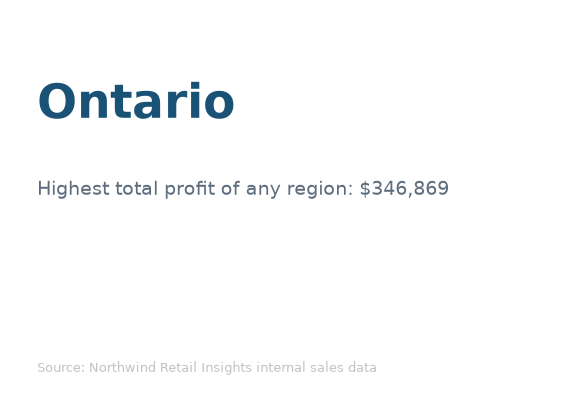

In [2]:
region_totals = sales.groupby("Region")["Profit"].sum().sort_values()
best_region = region_totals.idxmax()

fig, ax = plt.subplots(figsize=(7, 5))
ax.axis("off")

# 1: primary element -- large, bold, colored
ax.text(0.05, 0.72, best_region, fontsize=34, fontweight="bold", color="#1a5276")

# 2: secondary element -- medium, muted color
ax.text(0.05, 0.52,
        f"Highest total profit of any region: ${region_totals.max():,.0f}",
        fontsize=14, color="#5d6d7e")

# 3: tertiary element -- small, light gray
ax.text(0.05, 0.06, "Source: Northwind Retail Insights internal sales data",
        fontsize=9, color="#bdc3c7")

plt.show()

**Reflection:** Without reading any labels, in what order do your eyes land on the
three text elements? If someone glanced at this for only 2 seconds, what's the one
fact they'd walk away with?

_Your answer:_

The eye lands on the bold colored region name first, the muted supporting sentence
second, and the light gray footnote last, if at all. In a 2-second glance, the one
fact someone walks away with is "Ontario" -- the specific number and the source
footnote are there to back it up on a closer read, but the region name alone is
the takeaway a skim actually delivers.

## Task 2 — Make the Chart Accessible (Complaint #2)

**Real-world usage:** A colorblind or grayscale-printer viewer needs to be able to read
this chart too.

**Why this technique:** Redundant coding (color + pattern/shape) survives both
colorblindness and grayscale printing; color alone does not.

**TODO:**
1. Build a bar chart of total `Sales` by `Product Category`, one color per category.
2. Add a DIFFERENT hatch pattern per bar (`hatch="//"`, `"xx"`, `".."`) on top of the
   color, so the categories stay distinguishable if color is stripped away.
3. Add a legend showing category name.

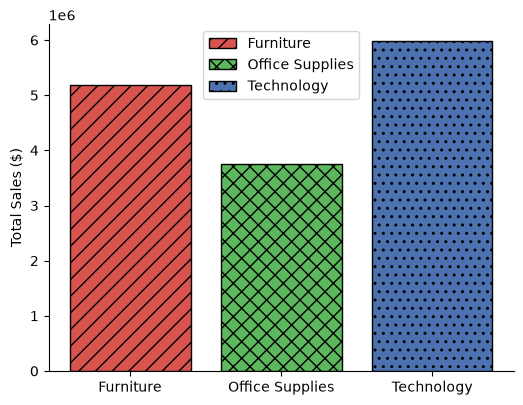

In [3]:
cat_sales = sales.groupby("Product Category")["Sales"].sum()

# 1 & 2: bars with both a distinct color AND a distinct hatch pattern per category
colors = {"Furniture": "#D9534F", "Office Supplies": "#5cb85c", "Technology": "#4C72B0"}
hatches = {"Furniture": "//", "Office Supplies": "xx", "Technology": ".."}

fig, ax = plt.subplots(figsize=(6, 4.5))
for cat in cat_sales.index:
    ax.bar(cat, cat_sales[cat], color=colors[cat], hatch=hatches[cat], edgecolor="black")

# 3: legend
handles = [mpatches.Patch(facecolor=colors[c], hatch=hatches[c], edgecolor="black", label=c)
           for c in cat_sales.index]
ax.legend(handles=handles)
ax.set_ylabel("Total Sales ($)")
plt.show()

**Reflection:** If you only used color (no hatch pattern), which two accessibility
failure modes from the lecture would this chart hit? Name both.

_Your answer:_

**Color-vision deficiency** -- a viewer with red-green color blindness may not be able
to reliably tell the red (Furniture) and green (Office Supplies) bars apart, even
though they look obviously different to someone with typical color vision. And
**grayscale printing/photocopying** -- red, green, and blue can convert to very
similar gray values once the color channel is stripped out, so all three bars could
end up looking nearly identical on a black-and-white printout, which is exactly the
failure mode the manager flagged.

## Task 3 — Catch the Axis Exaggeration (Complaint #3)

**Real-world usage:** A headline chart made a small real change look like a crisis.

**Why this technique:** Comparing the SAME data on a zero-baseline axis vs. a truncated
axis reveals exactly how much an axis choice is doing the "storytelling" instead of the
data.

**TODO:**
1. Compute total `Sales` by `Year`.
2. Compute the real percent change between the two most recent years.
3. Plot BOTH a zero-baseline version and a truncated-axis version, side by side, each
   titled with the real percent change.

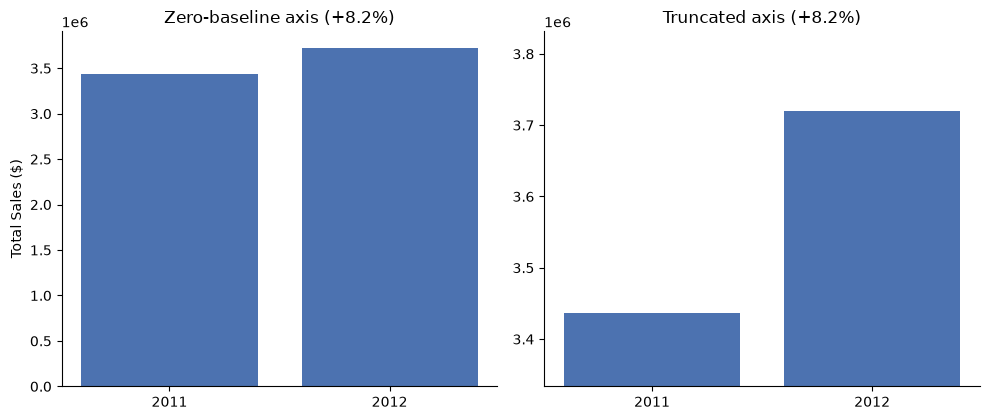

Real change from 2011 to 2012: +8.2%


In [4]:
yearly_sales = sales.groupby("Year")["Sales"].sum()

# 1 & 2: the two most recent years and their real percent change
y1, y2 = yearly_sales.index[-2], yearly_sales.index[-1]
v1, v2 = yearly_sales[y1], yearly_sales[y2]
pct_change = (v2 - v1) / v1 * 100

fig, axes = plt.subplots(1, 2, figsize=(10, 4.3))

# 3a: zero-baseline version (axes[0])
axes[0].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0")
axes[0].set_ylim(bottom=0)
axes[0].set_title(f"Zero-baseline axis ({pct_change:+.1f}%)")
axes[0].set_ylabel("Total Sales ($)")

# 3b: truncated-axis version (axes[1]) -- tight y-limits close to v1/v2
axes[1].bar([str(y1), str(y2)], [v1, v2], color="#4C72B0")
axes[1].set_ylim(min(v1, v2) * 0.97, max(v1, v2) * 1.03)
axes[1].set_title(f"Truncated axis ({pct_change:+.1f}%)")

plt.tight_layout()
plt.show()

print(f"Real change from {y1} to {y2}: {pct_change:+.1f}%")

**Reflection:** Which of your two panels would you flag for the manager as
potentially misleading if it were used ALONE as the report's headline chart, with no
other context? Why?

_Your answer:_

The **truncated-axis panel**. The real change from 2011 to 2012 is a modest +8.2%,
but on the truncated axis the second bar looks roughly two to three times taller than
the first, because the y-axis only spans a narrow band near the two values instead of
starting at zero. Anyone glancing at that panel alone -- exactly the "headline chart"
scenario -- would walk away thinking sales had a dramatic jump, when the honest,
zero-baseline version shows a real but modest single-digit percentage increase.

## Task 4 — Rewrite the Overreaching Annotation (Complaint #4)

**Real-world usage:** A colleague's annotation claimed a chart "PROVES" a strategy is
working — language the data alone cannot support.

**Why this technique:** Distinguishing descriptive / interpretive / persuasive
annotation lets you keep useful interpretation while cutting unsupported claims.

**TODO:**
1. Given the overreaching annotation text below, write a DESCRIPTIVE version (states
   only the fact) and an INTERPRETIVE version (explains a plausible, appropriately
   hedged reason) — no causal "PROVES" language in either.
2. Plot the yearly sales trend with your INTERPRETIVE annotation on the most recent
   data point.

ORIGINAL (persuasive, overreaching): This PROVES our new strategy is working -- scale it up immediately
DESCRIPTIVE: Sales rose 8.2% from 2011 to 2012.
INTERPRETIVE: Sales grew 8.2% in 2012, around the time the new strategy rolled out -- though seasonality, pricing changes, and broader market conditions could also be contributing, so this alone doesn't isolate the strategy's effect.


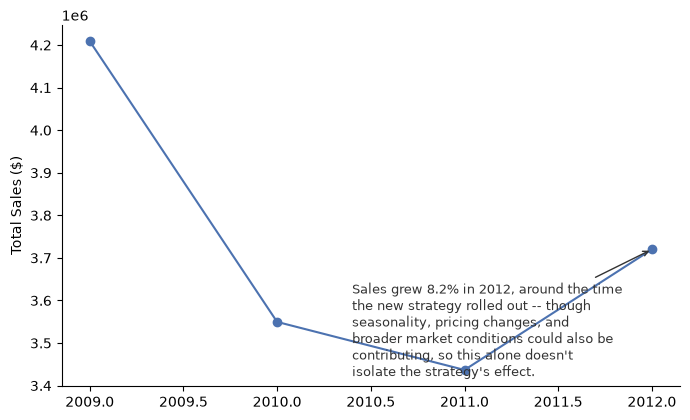

In [5]:
overreaching_original = "This PROVES our new strategy is working -- scale it up immediately"

# 1: your rewrites
descriptive_version = f"Sales rose {pct_change:.1f}% from {y1} to {y2}."
interpretive_version = (
    f"Sales grew {pct_change:.1f}% in {y2}, around the time the new strategy rolled out -- "
    f"though seasonality, pricing changes, and broader market conditions could also be "
    f"contributing, so this alone doesn't isolate the strategy's effect."
)

print("ORIGINAL (persuasive, overreaching):", overreaching_original)
print("DESCRIPTIVE:", descriptive_version)
print("INTERPRETIVE:", interpretive_version)

# 2: plot with your interpretive annotation on the last data point
import textwrap
fig, ax = plt.subplots(figsize=(7, 4.3))
ax.plot(yearly_sales.index, yearly_sales.values, "o-", color="#4C72B0")
ax.annotate(
    textwrap.fill(interpretive_version, 40),
    xy=(y2, v2), xytext=(y2 - 1.6, v2 * 0.92),
    fontsize=9, color="#333333",
    arrowprops=dict(arrowstyle="->", color="#333333"),
)
ax.set_ylabel("Total Sales ($)")
plt.tight_layout()
plt.show()

**Reflection:** What specific evidence would you need (that this dataset alone
doesn't provide) before the ORIGINAL "proves it's working" claim would actually be
justified?

_Your answer:_

I'd need something that isolates the strategy from everything else that changed at
the same time -- for example, a controlled comparison where some regions or stores
got the new strategy and comparable ones didn't (a holdout group), so the difference
in sales growth between the two could actually be attributed to the strategy rather
than to seasonality, pricing shifts, or general market conditions that year. One
year of aggregate sales going up, with no comparison group and no control for
confounds, just isn't strong enough evidence to justify a "proves" claim, no matter
how good the number looks.

## Task 5 — The Decision (No Code)

**Reflection (final):** Write a 4-6 sentence sign-off note to your manager summarizing
this review. Your answer should:
- State which ONE of the four fixes above you consider the most urgent to ship before
  tomorrow, and why.
- Reference the lecture's 5-question Ethical Visualization Audit — pick one question
  from it and explain how it applies to Task 3 or Task 4 specifically.
- Name one guardrail (a review step, a style-guide rule, etc.) you'd recommend
  permanently adding to the team's process to prevent these four issues recurring.

_Your final recommendation here:_

Of the four, I'd flag **Task 4's overreaching annotation as the most urgent to fix**
before tomorrow -- unlike the other three, which affect how a chart is *read*, this
one is attached to an explicit call to action ("scale it up immediately"), so if it
ships as-is it could directly drive a resourcing decision on evidence the data
doesn't actually support. One question from the ethical-visualization audit applies
here directly: whether the language accompanying a chart claims no more than the
data can actually support -- "PROVES" and "scale it up immediately" both fail that
test, since a single year's aggregate change with no control group can't establish
causation. The axis-truncation issue in Task 3 is a close second, since it's headed
for a headline chart. Going forward, I'd add a standing guardrail to our process: any
chart annotation using causal or certainty language ("proves," "guarantees,"
"always") automatically requires a second reviewer's sign-off before it can ship,
the same way we already require someone to double-check the axis on any chart
going into a headline slide.